# LeetCode #286: Walls and Gates

https://leetcode.com/problems/walls-and-gates/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (BFS from each empty room)** | $O((m \cdot n)^2)$ | $O(m \cdot n)$ |
| **Multi-source BFS (from all gates simultaneously)** | $O(m \cdot n)$ | $O(m \cdot n)$ |

---

## Understanding the Methods

### Brute Force (BFS from each empty room)
For every empty room (INF cell), run a separate BFS to find the nearest gate. Each BFS is $O(m \cdot n)$ and there are up to $m \cdot n$ empty rooms, giving $O((m \cdot n)^2)$ overall. Walls and gates are re-visited on every independent search.

### Optimal: Multi-source BFS (from all gates simultaneously) ★
Seed the queue with every gate (value 0) at once. Expand outward in BFS order — each cell is visited exactly once. When a neighbour is INF, update its distance to `current_distance + 1` and enqueue it. Since BFS guarantees shortest-path order, the first time a room is reached from any gate, that is its minimum distance.

**Why this is better than Brute Force:** All gates expand together, so each cell is processed exactly once regardless of how many gates exist. Total work is $O(m \cdot n)$.

**Constraints:**
* m == rooms.length, n == rooms[0].length
* 1 <= m, n <= 250
* rooms[i][j] is -1 (wall), 0 (gate), or 2^31 − 1 (empty room)

## Solutions

### C#

In [ ]:
public class Solution {
    private static readonly int INF = int.MaxValue;
    private static readonly int[][] Dirs = [[0,1],[0,-1],[1,0],[-1,0]];

    public void WallsAndGates(int[][] rooms) {
        int m = rooms.Length, n = rooms[0].Length;
        var queue = new Queue<(int r, int c)>();

        // Seed queue with every gate simultaneously
        for (int i = 0; i < m; i++)
            for (int j = 0; j < n; j++)
                if (rooms[i][j] == 0) queue.Enqueue((i, j));

        while (queue.Count > 0) {
            var (r, c) = queue.Dequeue();
            foreach (var d in Dirs) {
                int nr = r + d[0], nc = c + d[1];
                // Only update unvisited empty rooms
                if (nr < 0 || nr >= m || nc < 0 || nc >= n || rooms[nr][nc] != INF) continue;
                rooms[nr][nc] = rooms[r][c] + 1;
                queue.Enqueue((nr, nc));
            }
        }
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def wallsAndGates(self, rooms: list[list[int]]) -> None:
        INF = 2**31 - 1
        m, n = len(rooms), len(rooms[0])
        queue: deque = deque()

        # Seed queue with every gate simultaneously
        for i in range(m):
            for j in range(n):
                if rooms[i][j] == 0:
                    queue.append((i, j))

        while queue:
            r, c = queue.popleft()
            for dr, dc in [(0,1),(0,-1),(1,0),(-1,0)]:
                nr, nc = r + dr, c + dc
                # Only update unvisited empty rooms
                if 0 <= nr < m and 0 <= nc < n and rooms[nr][nc] == INF:
                    rooms[nr][nc] = rooms[r][c] + 1
                    queue.append((nr, nc))

### Go

In [ ]:
func wallsAndGates(rooms [][]int) {
    const INF = 1<<31 - 1
    m, n := len(rooms), len(rooms[0])
    dirs := [][2]int{{0,1},{0,-1},{1,0},{-1,0}}
    queue := [][2]int{}

    // Seed queue with every gate simultaneously
    for i := 0; i < m; i++ {
        for j := 0; j < n; j++ {
            if rooms[i][j] == 0 {
                queue = append(queue, [2]int{i, j})
            }
        }
    }
    for len(queue) > 0 {
        cell := queue[0]
        queue = queue[1:]
        r, c := cell[0], cell[1]
        for _, d := range dirs {
            nr, nc := r+d[0], c+d[1]
            // Only update unvisited empty rooms
            if nr >= 0 && nr < m && nc >= 0 && nc < n && rooms[nr][nc] == INF {
                rooms[nr][nc] = rooms[r][c] + 1
                queue = append(queue, [2]int{nr, nc})
            }
        }
    }
}

### Rust

In [ ]:
use std::collections::VecDeque;

impl Solution {
    pub fn walls_and_gates(rooms: &mut Vec<Vec<i32>>) {
        const INF: i32 = i32::MAX;
        let m = rooms.len();
        let n = rooms[0].len();
        let dirs: [(i32,i32);4] = [(0,1),(0,-1),(1,0),(-1,0)];
        let mut queue: VecDeque<(usize,usize)> = VecDeque::new();

        // Seed queue with every gate simultaneously
        for i in 0..m {
            for j in 0..n {
                if rooms[i][j] == 0 {
                    queue.push_back((i, j));
                }
            }
        }
        while let Some((r, c)) = queue.pop_front() {
            for (dr, dc) in dirs {
                let nr = r as i32 + dr;
                let nc = c as i32 + dc;
                if nr < 0 || nr >= m as i32 || nc < 0 || nc >= n as i32 { continue; }
                let (nr, nc) = (nr as usize, nc as usize);
                // Only update unvisited empty rooms
                if rooms[nr][nc] == INF {
                    rooms[nr][nc] = rooms[r][c] + 1;
                    queue.push_back((nr, nc));
                }
            }
        }
    }
}

## Example Scenarios

**1. Common Case**
**Input:** 4×4 grid with two gates at (1,2) and (0,3), walls at (0,2) and (1,3).
Multi-source BFS seeds both gates simultaneously. The BFS frontier expands one step at a time from both gates; each empty room gets labelled with the distance from whichever gate reaches it first. Result: every INF cell fills in with its correct minimum distance in a single $O(m \cdot n)$ pass.

**2. Slightly Complex**
**Input:** 3×3 grid with gate at (0,0), wall at (1,1).
Gate at (0,0) expands right and down. Room (1,1) is a wall — skipped. Rooms on the far side of the wall are reached by going around it. BFS naturally finds the shortest path around obstacles because it explores all directions equally before going deeper.

**3. Edge Case: Time Factor**
**Input:** $250 \times 250$ grid with a single gate at (0,0) and no walls.
The BFS frontier expands outward from (0,0) like concentric rings. Each of the $250^2 = 62500$ cells is visited exactly once. The corner cell (249,249) is filled last with distance 498. Total work is $O(m \cdot n) = O(62500)$ — the maximum possible.

**4. Edge Case: Space Factor**
**Input:** $250 \times 250$ grid of all gates (every cell = 0).
All 62500 cells are seeded into the initial queue simultaneously. The queue peaks at 62500 entries at initialization, but the BFS inner loop immediately finds no INF neighbours for any gate — so zero expansion happens. Peak queue memory is $O(m \cdot n)$.

**5. Almost-Impossible but Plausible**
**Input:** $250 \times 250$ grid with all cells as walls except one empty room, no gates.
All INF-check expansions are skipped immediately (every neighbour is either a wall or out of bounds). The BFS queue starts empty (no gates), the while-loop never executes. The lone INF room stays INF — correct, since it is unreachable from any gate. Total work: $O(m \cdot n)$ for the initial gate-scan, $O(1)$ BFS.

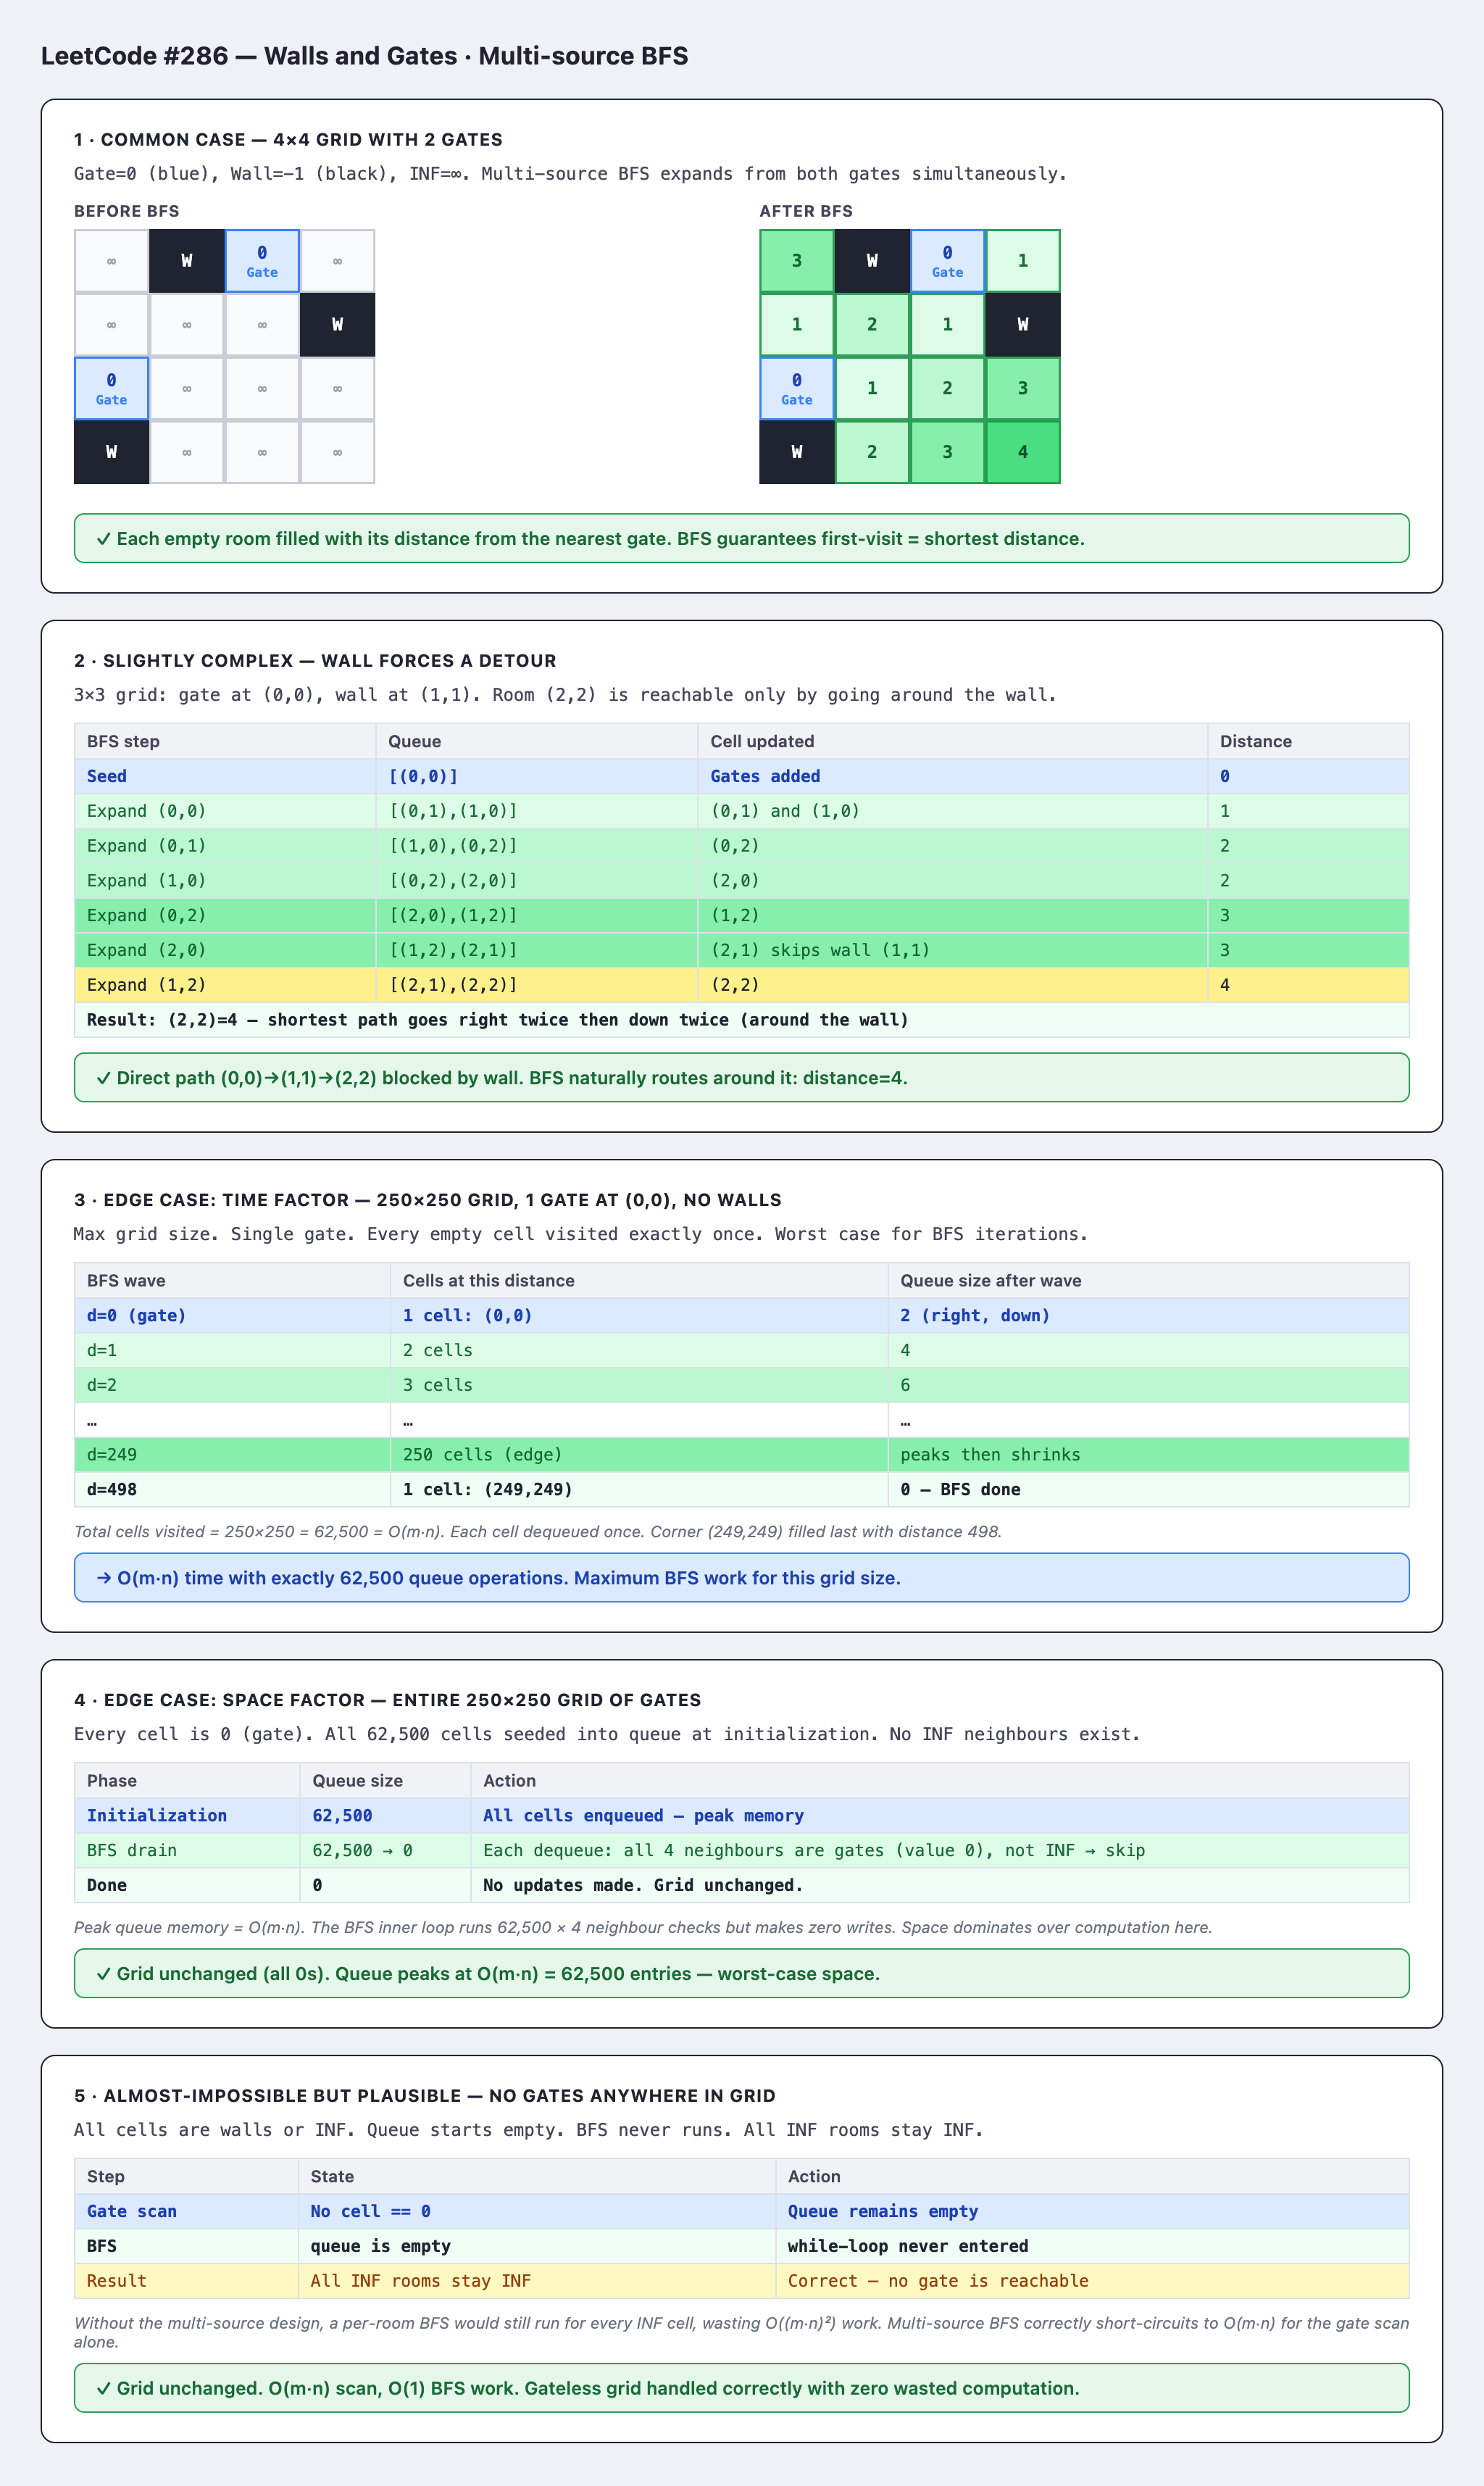